# 05 — Simulação de Ataques com Defesa GRADF Completa

Análoga à notebook 08 (`08_fl_attack_simulation.ipynb`), mas com `GRADFFederatedLearner` (detecção -> classificação -> seleção de defesa -> hardening -> XAI) no lugar de FedAvg/FLTrust puro — mede se o pipeline GRADF recupera a acurácia perdida sob diferentes tipos de ataque.

In [1]:
import sys, os
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd

from src.experiments.exp1_baseline import train_gradf_models
from src.fl.attacked_learner import AttackedFederatedLearner
from src.fl.gradf_learner import GRADFFederatedLearner
from src.utils.data_loader import load_dataset_participants

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

DATASET, SPLIT, N_CLIENTS, N_ROUNDS, N_CLASSES = 'mnist', 'non_iid', 10, 15, 10
BYZANTINE_FRACTION = 0.2
ATTACK_TYPES = ['sign_flipping', 'gaussian_noise', 'label_flipping']
participants, root_data = load_dataset_participants(DATASET, SPLIT, N_CLIENTS, data_root='../data/processed')
byzantine_ids = list(range(max(1, int(N_CLIENTS * BYZANTINE_FRACTION))))

I0000 00:00:1785808411.208679 1142971 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785808411.209320 1142971 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785808411.239506 1142971 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785808412.091821 1142971 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785808412.092174 1142971 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
results = {}
for attack_type in ATTACK_TYPES:
    print(f'--- {attack_type} ---')
    classifier, selector, attack_labels = train_gradf_models(
        participants, attack_type, BYZANTINE_FRACTION, N_CLASSES, seed=1)

    baseline = AttackedFederatedLearner(
        n_rounds=N_ROUNDS, aggregation='fedavg', n_classes=N_CLASSES,
        attack_type=attack_type, byzantine_ids=byzantine_ids)
    baseline_hist = baseline.train(participants, verbose=False)

    gradf = GRADFFederatedLearner(
        n_rounds=N_ROUNDS, aggregation='fedavg', n_classes=N_CLASSES,
        attack_type=attack_type, byzantine_ids=byzantine_ids,
        classifier=classifier, selector=selector, attack_labels=attack_labels)
    gradf_hist = gradf.train(participants, verbose=False)

    results[attack_type] = {
        'fedavg': [r.global_accuracy for r in baseline_hist],
        'gradf': [r.global_accuracy for r in gradf_hist],
    }
    print(f'  fedavg final={results[attack_type]["fedavg"][-1]:.4f}  '
          f'gradf final={results[attack_type]["gradf"][-1]:.4f}')

--- sign_flipping ---


E0000 00:00:1785808424.421181 1142971 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1785808424.437894 1142971 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


  fedavg final=0.7819  gradf final=0.8890
--- gaussian_noise ---


  fedavg final=0.6496  gradf final=0.8939
--- label_flipping ---


  fedavg final=0.8118  gradf final=0.8780


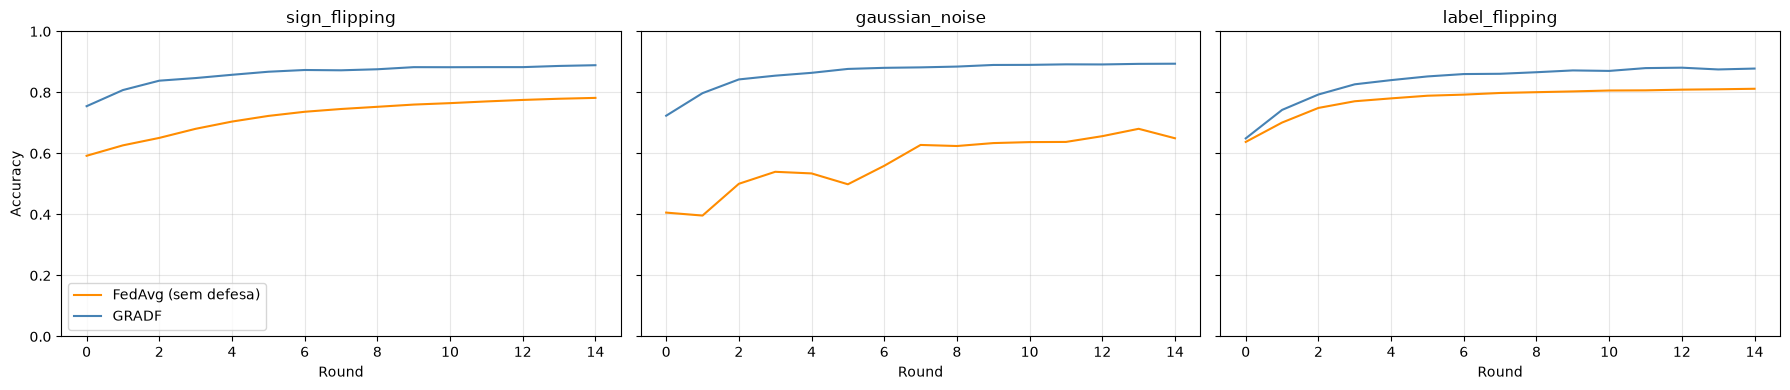

In [3]:
fig, axes = plt.subplots(1, len(ATTACK_TYPES), figsize=(6 * len(ATTACK_TYPES), 4), sharey=True)
for ax, attack_type in zip(axes, ATTACK_TYPES):
    ax.plot(results[attack_type]['fedavg'], label='FedAvg (sem defesa)', color='darkorange')
    ax.plot(results[attack_type]['gradf'], label='GRADF', color='steelblue')
    ax.set_title(attack_type); ax.set_xlabel('Round'); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
axes[0].set_ylabel('Accuracy'); axes[0].legend()
plt.tight_layout()
plt.savefig('../results/figures/05_attack_simulation_gradf.png', bbox_inches='tight')
plt.show()

In [4]:
summary = pd.DataFrame({
    attack_type: {'fedavg_final': v['fedavg'][-1], 'gradf_final': v['gradf'][-1]}
    for attack_type, v in results.items()
}).T
summary.index.name = 'attack_type'
summary.to_csv('../results/tables/05_attack_simulation_gradf.csv')
summary

,fedavg_final,gradf_final
attack_type,,
sign_flipping,0.7819,0.8890
gaussian_noise,0.6496,0.8939
label_flipping,0.8118,0.8780
